# Assignment 2


## Task

Fetch the diagnostic Wisconsin breast cancer dataset from the above link and study the associated description. The problem task consists of building a classifier using the kNN algorithm to predict the binary-valued target variable "Diagnosis" in the data. Also, the performance of the classifier must be investigated and reported.

Prepare a Jupyter notebook containing a full account of the problem treatment, conducted according to the CRISP-DM process model. The notebook should pay attention to the following issues:

-Investigate the contents of the dataset and include a brief description of its variables.

-Apply standardization to the numerical values of the input variables.

-Extract part of the data for testing in accordance with the hold-out validation technique.

-Train a binary classifier for predicting the cancer diagnosis (malignant / benign). Experiment with a few choices of the hyperparameter k, and report the findings.

-Test the performance of the classifier and present the associated confusion matrix together with the most common evaluation metrics (accuracy, precision and recall).

Construct your notebook to include sections for each of the six separate stages in the CRISP-DM model, with appropriate contents. Remember to draw conclusions and interpret your findings.

## CRISP-DM

This notebook follows the CRISP-DM process model

CRISP-DM phases:

1. Business understanding: The first phase is to understand the business problem that needs to be solved. What is the goal of the analysis? What are the requirements and constraints? What is the expected outcome?

2. Data understanding: The second phase is to collect and explore the data. What data is available? What are the characteristics of the data (variable types, value distributions etc.)? Are there any quality issues with the data (missing values, outliers, nonsensical values)?

3. Data preparation: The third phase is to preprocess the data. This includes cleaning the data, transforming the data, and selecting the relevant features. These steps should be documented in such detail that they can be reproduced later.

4. Modeling: The fourth phase is to choose a machine learning method and train the model. This phase also includes the validation of the model. Documentation needs include: which method was used, which parameters were used, what was the performance of the model?

5. Evaluation: The fifth phase is to evaluate the model. How well does the model perform? Does it meet the business requirements?

6. Deployment: The final phase is to deploy the model. How will the model be used in practice? How will the results be communicated? This phase may involve creating a recommendation of how to use the model in practice, or what to do next.

## 1. Business understanding


Task: "The problem task consists of building a classifier using the kNN algorithm to predict the binary-valued target variable "Diagnosis" in the data. Also, the performance of the classifier must be investigated and reported."

Goal of this analysis is to demonstrate how a kNN classifier could be trained on the given dataset and used to make predictions about breast cancer diagnosis.

## 2. Data understanding

### 2.1 Description of variables from data source:

"Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.  They describe characteristics of the cell nuclei present in the image."

### 2.2 Types of variables

	a) radius (mean of distances from center to points on the perimeter)
	b) texture (standard deviation of gray-scale values)
	c) perimeter
	d) area
	e) smoothness (local variation in radius lengths)
	f) compactness (perimeter^2 / area - 1.0)
	g) concavity (severity of concave portions of the contour)
	h) concave points (number of concave portions of the contour)
	i) symmetry
	j) fractal dimension ("coastline approximation" - 1)


### 2.3 List of all variables
|               |               |               |
| :------------ | :-----------: | ------------: |
| ID |  	ID |  	Categorical |
| Diagnosis |   	Target |  	Categorical |
| radius1 | 	Feature | 	Continuous |
| texture1 |    	Feature | 	Continuous |
| perimeter1 |  	Feature | 	Continuous |
| area1 |   	Feature | 	Continuous |
| smoothness1 | 	Feature | 	Continuous |
| compactness1 |    	Feature | 	Continuous |
| concavity1 |  	Feature | 	Continuous |
| concave_points1 | 	Feature | 	Continuous |
| symmetry1 |   	Feature | 	Continuous |
| fractal_dimension1 |  	Feature | 	Continuous |
| radius2 | 	Feature | 	Continuous |
| texture2 |    	Feature | 	Continuous |
| perimeter2 |  	Feature | 	Continuous |
| area2 |   	Feature | 	Continuous |
| smoothness2 | 	Feature | 	Continuous |
| compactness2 |    	Feature | 	Continuous |
| concavity2 |  	Feature | 	Continuous |
| concave_points2 | 	Feature | 	Continuous |
| symmetry2 |   	Feature | 	Continuous |
| fractal_dimension2 |  	Feature | 	Continuous |
| radius3 | 	Feature | 	Continuous |
| texture3 |    	Feature | 	Continuous |
| perimeter3 |  	Feature | 	Continuous |
| area3 |   	Feature |	    Continuous |
| smoothness3 | 	Feature |	    Continuous |
| compactness3 |    	Feature |	    Continuous |
| concavity3 |  	Feature |	    Continuous |
| concave_points3 | 	Feature |	    Continuous |
| symmetry3 |   	Feature |	    Continuous |
| fractal_dimension3 |	    Feature |	    Continuous |





### 2.4 Importing the data

In [146]:
#importing the data

# breast cancer data is available in ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools


# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data
features : DataFrame = breast_cancer_wisconsin_diagnostic.data.features
targets : DataFrame = breast_cancer_wisconsin_diagnostic.data.targets

# metadata and variables info
metadata : DataFrame = breast_cancer_wisconsin_diagnostic.metadata
variables : DataFrame = breast_cancer_wisconsin_diagnostic.variables

### 2.5 Features & Metadata

In [147]:
# example of data
features.head(5)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [148]:
# metadata
metadata

{'uci_id': 17,
 'name': 'Breast Cancer Wisconsin (Diagnostic)',
 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic',
 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv',
 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.',
 'area': 'Health and Medicine',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 569,
 'num_features': 30,
 'feature_types': ['Real'],
 'demographics': [],
 'target_col': ['Diagnosis'],
 'index_col': ['ID'],
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1993,
 'last_updated': 'Fri Nov 03 2023',
 'dataset_doi': '10.24432/C5DW2B',
 'creators': ['William Wolberg',
  'Olvi Mangasarian',
  'Nick Street',
  'W. Street'],
 'intro_paper': {'ID': 230,
  'type': 'NATIVE',
  'title': 'Nuclear feature extraction for breast tumor diagnosis',
  'authors': 'W. Street, W. Wolberg, O. Mangasarian',
  'venue': 'Electronic imaging',
  'yea

### 2.6 Variables

Notably the dataset should not have any missing variables.

In [149]:
# variable information
variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Categorical,None,None,None,no
1,Diagnosis,Target,Categorical,None,None,None,no
2,radius1,Feature,Continuous,None,None,None,no
3,texture1,Feature,Continuous,None,None,None,no
4,perimeter1,Feature,Continuous,None,None,None,no
5,area1,Feature,Continuous,None,None,None,no
6,smoothness1,Feature,Continuous,None,None,None,no
7,compactness1,Feature,Continuous,None,None,None,no
8,concavity1,Feature,Continuous,None,None,None,no
9,concave_points1,Feature,Continuous,None,None,None,no


Only datatype is float64:

In [150]:
features.dtypes.unique()

array([dtype('float64')], dtype=object)

### 2.7 Data Understanding: Summary

- There are 10 different types of features
- Each data entry has these variables for 3 measurement points for 30 features total
- Additional variable is Diagnosis target for 31 variables total per entry
- ID is listed as a variable but is not a column in data
- Only datatype of features is float64
- Dataset should not have missing values
- Dataset does not specify units
- All variables are continuous, except ID and Diagnosis which are categorical



### 2.8 Data Understanding: Conclusions

- Data should be standardized
- Since ID is not a column, care should be taken when deleting or sorting the data to keep features and targets list indexes equivalent.
-


## 3. Data Preparation

In [151]:
# TODO: Data preparation: The third phase is to preprocess the data. This includes cleaning the data, transforming the data, and selecting the relevant features. These steps should be documented in such detail that they can be reproduced later.


### 3.1 Standardization of data

Features were standardized with StandardScaler.

In [152]:
# task: -Apply standardization to the numerical values of the input variables.

# confirm that no null entries actually exist
assert all(features.notna())
assert all(targets.notna())

# scale the data by standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# this code can be used to replace Diagnosis abbreviations with other value if needed later
targets = targets.replace( {"M": "Malignant", "B": "Benign"})
assert all( value in ["Malignant","Benign"] for value in targets["Diagnosis"] )


### 3.2 Separating training and testing data

Dataset was split with a hold-out (split) technique using train_test_split method from sklearn.

In [153]:
# task: -Extract part of the data for testing in accordance with the hold-out validation technique.

from sklearn.model_selection import train_test_split

# sort the combined data into separate datasets for model training and testing, using scaled feature set and enumerated target diagnosis
features_train, features_test, target_train, target_test = train_test_split(features_scaled, targets, test_size=0.25, random_state=69)

# assert the lists
assert len(features_train) == len(target_train) and len(features_test) == len(target_test)

## 4. Modeling

In [154]:
# TODO: Modeling: The fourth phase is to choose a machine learning method and train the model. This phase also includes the validation of the model. Documentation needs include: which method was used, which parameters were used, what was the performance of the model?


### 4.1 Baseline Model

Training a model without tweaking hyperparameters can be used as a baseline for comparison to other models.

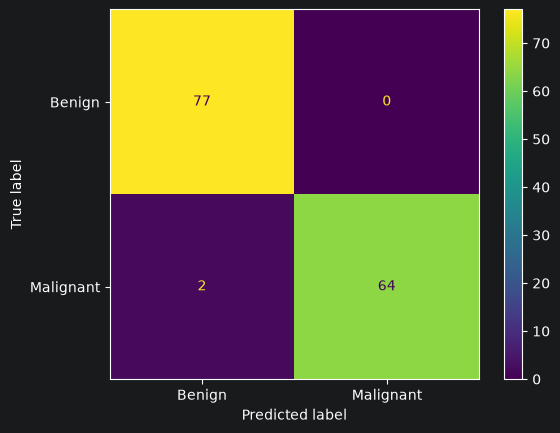

In [163]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# train the model with training data
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(features_train, target_train["Diagnosis"] ) # note: target_train is not a list but a dataframe with 1 column "Diagnosis"

# use test data for test predictions
test_predictions = model.predict(features_test)

# confusion matrix of predicted class vs actual  model.classes_ returns the unique values available in target data
cm  = confusion_matrix(target_test, test_predictions, labels=model.classes_)
cmd = ConfusionMatrixDisplay(cm, display_labels=model.classes_ )
cmd.plot()


### 4.2 Other Models

Training k-NN models wih different hyperparameters (k)

In [ ]:
# TODO: task: -Train a binary classifier for predicting the cancer diagnosis (malignant / benign). Experiment with a few choices of the hyperparameter k, and report the findings.

## 5. Evaluation

In [156]:
# TODO: Evaluation: The fifth phase is to evaluate the model. How well does the model perform? Does it meet the business requirements?
# TODO: task: -Test the performance of the classifier and present the associated confusion matrix together with the most common evaluation metrics (accuracy, precision and recall).

## 6. Deployment

In [157]:
# TODO: Deployment: The final phase is to deploy the model. How will the model be used in practice? How will the results be communicated? This phase may involve creating a recommendation of how to use the model in practice, or what to do next.